In [1]:
import numpy as np

In [2]:
def my_lu(A,pivoting=None):
    
    """
    This function factors A = LU (if pivoting=None; default) or PA = LU (if pivoting='partial')
    INPUT:
        matrix A
    OUTPUT:
        permutation vector p (if pivoting == 'partial')
        lower triangular factor L
        upper triangular factor U
    """
    
    n,m = A.shape # size of matrix A
    if m!=n: # check if A is square
        print('WARNING: A must be a square matrix') # print a warning massage
        return  
    
    # initialize factors L and U
    U = A.copy()
    L = np.identity(n)
    
    # initialize permutation vector p = [0,1,...,n-1]
    if pivoting == 'partial':
        p = np.arange(n)
    
    # GAUSSIAN ELIMINATION 
    for i in range(n):  # loop over columns 1,...,n (first loop)
        if pivoting=='partial':
            # Find the entry with largest absolute value
            row2swap = i + np.argmax(np.abs(U[i:n,i]))
            # swap rows of U
            U[[row2swap,i],i:n] = U[[i,row2swap],i:n]
            # swap multipliers
            L[[row2swap,i],0:i] = L[[i,row2swap],0:i] 
            # update permutation vector p
            p[[row2swap,i]]=p[[i,row2swap]]
        # multipliers 
        L[i+1:n,i] = U[i+1:n,i]/U[i,i] 
        # update U
        U[i+1:n,i] = 0 
        U[i+1:n,i+1:n] = U[i+1:n,i+1:n] - np.outer(L[i+1:n,i],U[i,i+1:n]) # update U
    
    if pivoting=='partial':
        return L,U,p
    else:
        return L,U

## Small Pivots (Large Multipliers) -> Large Errors

A = $[[10^{-16},1],[1,1]] = [[1,0],[10^{16},1]]\cdot[[10^{-16},1],[0,1-10^{16}]]$

But using our function, we got $[[10^{-16},1],[1,1]] = [[1,0],[10^{16},1]]\cdot[[10^{-16},1],[0,-10^{16}]]=[[10^{-16},1],[1,0]]$, and the last entry is wrong

In [3]:
# Lets test our funKshun
A = 1.0*np.array([[2,4,-2],[4,9,-3],[-2,-3,7]])
A

array([[ 2.,  4., -2.],
       [ 4.,  9., -3.],
       [-2., -3.,  7.]])

In [4]:
L,U,p = my_lu(A,pivoting='partial')

In [5]:
# check that PA = LU
L.dot(U)

array([[ 4.,  9., -3.],
       [-2., -3.,  7.],
       [ 2.,  4., -2.]])

In [6]:
A[p]

array([[ 4.,  9., -3.],
       [-2., -3.,  7.],
       [ 2.,  4., -2.]])

In [7]:
L.dot(U)==A[p]

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True, False]])

## To solve Ax = b

1) First, factor $PA=LU$ (GEPP)

2) Permute $Pb$

3) Solve $Ly = Pb$

4) Solve $Ux = y$

5) $x$ solves the linear system.

In [8]:
def my_solve(A,b,pivoting=None):
    'this function solves Ax=b'

    # size of the problem
    n = len(b)
    
    # initialize vectors x and y
    y = np.zeros(n)
    x = np.zeros(n)

    # compute LU factorization
    if pivoting==None:
        L,U = my_lu(A,pivoting)
        bp=b
        
    else:
        L,U,p = my_lu(A,pivoting)
        #permute b
        bp= b[p]

    # solve Ly = b
    for i in range(n):
        y[i] = bp[i] - L[i,0:i].dot(y[0:i])

    # solve Ux = y
    for i in reversed(range(n)): # i = n,...,1
        x[i] = (y[i] - U[i,i+1:n].dot(x[i+1:n]))/U[i,i]

    return x

In [9]:
A = np.array([[10**-16,1],[1,1]])
b= np.array([1,0])

my_solve(A,b,pivoting='partial')

array([-1.,  1.])

In [10]:
my_solve(A,b,pivoting=None)

array([0., 1.])

In [11]:
import time

In [12]:
# cost of GEPP

n_list = [10**(i+1) for i in range(4)]
t = []
for n in n_list:
    A = np.random.randn(n,n)
    b = np.random.randn(n)
    start = time.time()
    x = np.linalg.solve(A,b)
    end = time.time()
    t.append(end-start)
    print(n)

10
100
1000
10000


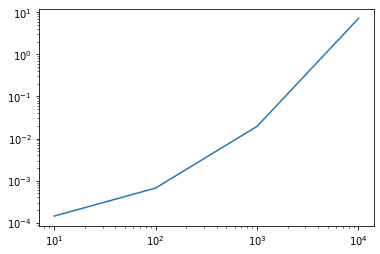

In [13]:
import matplotlib.pyplot as plt
plt.loglog(n_list,t)

In [1]:
def my_solve_plu(L,U,p,b,pivoting=None):
    'given PA = LU, this function solves Ax=b'

    # size of the problem
    n = len(b)
    
    # initialize vectors x and y
    y = np.zeros(n)
    x = np.zeros(n)
    
    # permute b
    bp = b[p]

    # solve Ly = bp
    for i in range(n):
        y[i] = bp[i] - L[i,0:i].dot(y[0:i])

    # solve Ux = y
    for i in reversed(range(n)): # i = n,...,1
        x[i] = (y[i] - U[i,i+1:n].dot(x[i+1:n]))/U[i,i]

    return x